---

# <center>AI / ML Project - Sentiment Analysis

---

<center> <img src="https://raw.githubusercontent.com/Masterx-AI/Project_Twitter_Sentiment_Analysis_/main/twitt.jpg" style="width: 700px; align:center"/>

---

### Description:

Twitter is an online Social Media Platform where people share their their though as tweets. It is observed that some people misuse it to tweet hateful content. Twitter is trying to tackle this problem and we shall help it by creating a strong NLP based-classifier model to distinguish the negative tweets & block such tweets. Can you build a strong classifier model to predict the same?

Each row contains the text of a tweet and a sentiment label. In the training set you are provided with a word or phrase drawn from the tweet (selected_text) that encapsulates the provided sentiment.

Make sure, when parsing the CSV, to remove the beginning / ending quotes from the text field, to ensure that you don't include them in your training.

You're attempting to predict the word or phrase from the tweet that exemplifies the provided sentiment. The word or phrase should include all characters within that span (i.e. including commas, spaces, etc.)

#### Columns:
1. textID - unique ID for each piece of text
2. text - the text of the tweet
3. sentiment - the general sentiment of the tweet

#### Acknowledgement:
The dataset is download from Kaggle Competetions:\
https://www.kaggle.com/c/tweet-sentiment-extraction/data?select=train.csv

### Objective:
- Understand the Dataset & cleanup (if required).
- Build classification models to predict the twitter sentiments.
- Compare the evaluation metrics of vaious classification algorithms.

In [69]:
!pip install scipy nltk wordcloud

---

## <center>1. Data Exploration

In [70]:
import math
import nltk
import scipy
import string
import numpy as np
import pandas as pd
import seaborn as sns

from tqdm import tqdm
from scipy.stats import randint
from wordcloud import WordCloud
from multiprocessing import Pool
from nltk.corpus import stopwords
from scipy.stats import loguniform

from sklearn.decomposition import PCA
from nltk.stem.porter import PorterStemmer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, \
roc_auc_score, roc_curve, precision_score, recall_score

from IPython.display import display

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,6]

import warnings
warnings.filterwarnings('ignore')

In [71]:
df = pd.read_csv('Tweets.csv', header=0)
df.drop(['textID'], axis=1, inplace=True)
target = 'sentiment'

missing_text_mask = df['text'].isnull()
if missing_text_mask.any():
    df.loc[missing_text_mask & df['selected_text'].notna(), 'text'] = \
        df.loc[missing_text_mask & df['selected_text'].notna(), 'selected_text']

    remaining_missing = df['text'].isnull()
    for idx in df[remaining_missing].index:
        sentiment = df.loc[idx, 'sentiment']
        df.loc[idx, 'text'] = f"{sentiment} sentiment"

df.drop(['selected_text'], axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
original_df = df.copy(deep=True)
display(df.head())

print(f'\nDataset: {df.shape[1]} features & {df.shape[0]} samples')

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative



Dataset: 2 features & 27481 samples


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       27481 non-null  object
 1   sentiment  27481 non-null  object
dtypes: object(2)
memory usage: 429.5+ KB


In [73]:
display(df.describe())

,text,sentiment
count,27481,27481
unique,27481,3
top,"I`d have responded, if I were going",neutral
freq,1,11118


**Inference:** The stats seem to be fine, let us gain more undestanding by visualising the dataset.

---

## <center> 2. Data Preprocessing

In [74]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hiruzen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [75]:
print(df.isnull().sum())
print(f"\nTotal samples: {len(df)}")

text         0
sentiment    0
dtype: int64

Total samples: 27481


## Enhanced Text Preprocessing with Feature Engineering

Instead of basic preprocessing, we'll:
1. Preserve sentiment-rich information (emoticons, punctuation, capitalization)
2. Keep negations which are critical for sentiment
3. Extract additional features that indicate sentiment
4. Use bigrams to capture phrase-level context

In [76]:
import re
from collections import Counter

def enhanced_preprocessor(text, extract_features=False):
    features = {}

    if extract_features:
        # Extract features before preprocessing
        features['exclamation_count'] = text.count('!')
        features['question_count'] = text.count('?')
        features['caps_ratio'] = sum(1 for c in text if c.isupper()) / max(len(text), 1)
        features['has_url'] = 1 if 'http' in text.lower() else 0
        features['has_mention'] = 1 if '@' in text else 0
        features['has_hashtag'] = 1 if '#' in text else 0

    text = re.sub(r'(.)\1{2,}', r'\1\1\1', text)

    text = re.sub(r'http\S+|www\S+', ' urltoken ', text)

    text = re.sub(r'@\w+', ' mentiontoken ', text)

    text = re.sub(r'#(\w+)', r'\1', text)

    emoticons = {
        ':)': ' happyemoji ', ':(': ' sademoji ', ':D': ' happyemoji ',
        ';)': ' happyemoji ', ':P': ' playfulemoji ', ':/': ' confusedemoji ',
        ':|': ' neutralemoji ', ':O': ' surprisedemoji ', '<3': ' loveemoji '
    }
    for emoticon, replacement in emoticons.items():
        text = text.replace(emoticon, replacement)

    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = ' '.join(text.split())
    stemmer = PorterStemmer()
    text = ' '.join(stemmer.stem(word) for word in text.split())
    important_words = {'not', 'no', 'never', 'neither', 'nobody', 'nothing', 'nor'}
    stop_words_filtered = set(stopwords.words("english")) - important_words
    text = ' '.join(word for word in text.split() if word not in stop_words_filtered)

    if extract_features:
        return text, features
    return text
sample_texts = [
    "I'm sooooo happy!!! 😊 #blessed",
    "This is terrible :( @customer_service",
    "Not bad at all, actually pretty good!",
    "http://example.com check this out!!!!"
]

print("Enhanced Preprocessing Examples:")
print("=" * 80)
for text in sample_texts:
    processed, features = enhanced_preprocessor(text, extract_features=True)
    print(f"\nOriginal: {text}")
    print(f"Processed: {processed}")
    print(f"Features: {features}")

Enhanced Preprocessing Examples:

Original: I'm sooooo happy!!! 😊 #blessed
Processed: sooo happi bless
Features: {'exclamation_count': 3, 'question_count': 0, 'caps_ratio': 0.03333333333333333, 'has_url': 0, 'has_mention': 0, 'has_hashtag': 1}

Original: This is terrible :( @customer_service
Processed: thi terribl sademoji mentiontoken
Features: {'exclamation_count': 0, 'question_count': 0, 'caps_ratio': 0.02702702702702703, 'has_url': 0, 'has_mention': 1, 'has_hashtag': 0}

Original: Not bad at all, actually pretty good!
Processed: not bad actual pretti good
Features: {'exclamation_count': 1, 'question_count': 0, 'caps_ratio': 0.02702702702702703, 'has_url': 0, 'has_mention': 0, 'has_hashtag': 0}

Original: http://example.com check this out!!!!
Processed: urltoken check thi
Features: {'exclamation_count': 4, 'question_count': 0, 'caps_ratio': 0.0, 'has_url': 1, 'has_mention': 0, 'has_hashtag': 0}


In [77]:
print("Applying enhanced preprocessing to dataset...")
df_improved = df.copy()
df_improved['text_processed'] = [enhanced_preprocessor(t) for t in tqdm(df_improved['text'])]

print("\nExtracting additional features...")
features_list = []
for text in tqdm(df_improved['text']):
    _, features = enhanced_preprocessor(text, extract_features=True)
    features_list.append(features)

features_df = pd.DataFrame(features_list)
print("\nExtracted features summary:")
print(features_df.describe())

df_with_features = pd.concat([df_improved, features_df], axis=1)
print(f"\nDataset shape with features: {df_with_features.shape}")
print(df_with_features.head())

Applying enhanced preprocessing to dataset...


100%|██████████| 27481/27481 [00:03<00:00, 7612.48it/s]



Extracting additional features...


100%|██████████| 27481/27481 [00:04<00:00, 6394.80it/s]




Extracted features summary:
       exclamation_count  question_count    caps_ratio       has_url  \
count       27481.000000    27481.000000  27481.000000  27481.000000   
mean            0.556603        0.155235      0.044575      0.044503   
std             1.316122        0.922581      0.077849      0.206215   
min             0.000000        0.000000      0.000000      0.000000   
25%             0.000000        0.000000      0.000000      0.000000   
50%             0.000000        0.000000      0.028571      0.000000   
75%             1.000000        0.000000      0.054054      0.000000   
max            59.000000       98.000000      1.000000      1.000000   

        has_mention   has_hashtag  
count  27481.000000  27481.000000  
mean       0.010626      0.019723  
std        0.102533      0.139048  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        0.000000      0.000000  
75%        0.000000      0.000000  
max        1.000000      1.000000 

In [78]:
# Improved TF-IDF Vectorizer with N-grams
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf_improved = TfidfVectorizer(
    strip_accents=None,
    lowercase=False,
    preprocessor=None,
    tokenizer=lambda x: x.split(),
    use_idf=True,
    norm='l2',
    smooth_idf=True,
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.8
)

y_improved = df_with_features['sentiment'].values
X_text_improved = tfidf_improved.fit_transform(df_with_features['text_processed'])

print(f"TF-IDF matrix shape: {X_text_improved.shape}")
print(f"Number of features from TF-IDF: {X_text_improved.shape[1]}")

additional_features = df_with_features[['exclamation_count', 'question_count',
                                        'caps_ratio', 'has_url', 'has_mention',
                                        'has_hashtag']].values

print(f"Additional features shape: {additional_features.shape}")

from scipy.sparse import csr_matrix
X_combined = hstack([X_text_improved, csr_matrix(additional_features)])

print(f"\nCombined feature matrix shape: {X_combined.shape}")
print(f"Total features: {X_combined.shape[1]}")
print(f"  - Text features (TF-IDF): {X_text_improved.shape[1]}")
print(f"  - Additional features: {additional_features.shape[1]}")

TF-IDF matrix shape: (27481, 10000)
Number of features from TF-IDF: 10000
Additional features shape: (27481, 6)

Combined feature matrix shape: (27481, 10006)
Total features: 10006
  - Text features (TF-IDF): 10000
  - Additional features: 6


## Data Augmentation

Data augmentation techniques for text:
1. **Synonym Replacement** - Replace words with synonyms
2. **Back Translation** - Translate to another language and back
3. **Random Insertion** - Insert random synonyms
4. **Random Swap** - Swap word positions
5. **Paraphrasing** - Rephrase while maintaining sentiment

For this example, we'll use simple augmentation techniques.

In [79]:
import random
import numpy as np

# Simple Data Augmentation Functions for Text
def random_swap(words, n=1):
    """Randomly swap n word positions"""
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) >= 2:
            idx1, idx2 = random.sample(range(len(new_words)), 2)
            new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

def random_deletion(words, p=0.1):
    """Randomly delete words with probability p"""
    if len(words) == 1:
        return words
    new_words = [word for word in words if random.random() > p]
    if len(new_words) == 0:
        return [random.choice(words)]
    return new_words

def augment_text(text, num_aug=1):
    """Augment a single text sample"""
    words = text.split()
    augmented_texts = []

    for _ in range(num_aug):
        # Randomly choose augmentation method
        choice = random.choice(['swap', 'delete'])

        if choice == 'swap' and len(words) >= 2:
            new_words = random_swap(words, n=max(1, len(words)//5))
        else:
            new_words = random_deletion(words, p=0.1)

        augmented_texts.append(' '.join(new_words))

    return augmented_texts

# Augment the dataset - focus on minority classes to balance
print("Analyzing class distribution...")
sentiment_counts = df_with_features['sentiment'].value_counts()
print(sentiment_counts)

# Find minority classes that need more samples
max_count = sentiment_counts.max()
augmentation_needed = {}
for sentiment, count in sentiment_counts.items():
    if count < max_count * 0.9:  # If class has <90% of max class
        augmentation_needed[sentiment] = int((max_count * 0.9 - count) * 0.3)  # Augment 30% of deficit

print(f"\nAugmentation plan: {augmentation_needed}")

# Perform augmentation
augmented_rows = []
for sentiment, num_samples in augmentation_needed.items():
    if num_samples > 0:
        # Get samples from this class
        class_samples = df_with_features[df_with_features['sentiment'] == sentiment]

        # Randomly sample rows to augment
        samples_to_augment = class_samples.sample(n=min(num_samples, len(class_samples)),
                                                   replace=True, random_state=42)

        for idx, row in samples_to_augment.iterrows():
            augmented_text = augment_text(row['text_processed'], num_aug=1)[0]

            # Create new row with augmented text
            new_row = row.copy()
            new_row['text'] = augmented_text  # Keep original for reference
            new_row['text_processed'] = augmented_text
            augmented_rows.append(new_row)

if augmented_rows:
    augmented_df = pd.DataFrame(augmented_rows)
    df_augmented = pd.concat([df_with_features, augmented_df], ignore_index=True)
    print(f"\nOriginal dataset size: {len(df_with_features)}")
    print(f"Augmented samples added: {len(augmented_df)}")
    print(f"Final dataset size: {len(df_augmented)}")
    print(f"\nNew class distribution:")
    print(df_augmented['sentiment'].value_counts())
else:
    df_augmented = df_with_features.copy()
    print("\nNo augmentation needed - dataset is balanced")

Analyzing class distribution...
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

Augmentation plan: {'positive': 427, 'negative': 667}

Original dataset size: 27481
Augmented samples added: 1094
Final dataset size: 28575

New class distribution:
sentiment
neutral     11118
positive     9009
negative     8448
Name: count, dtype: int64


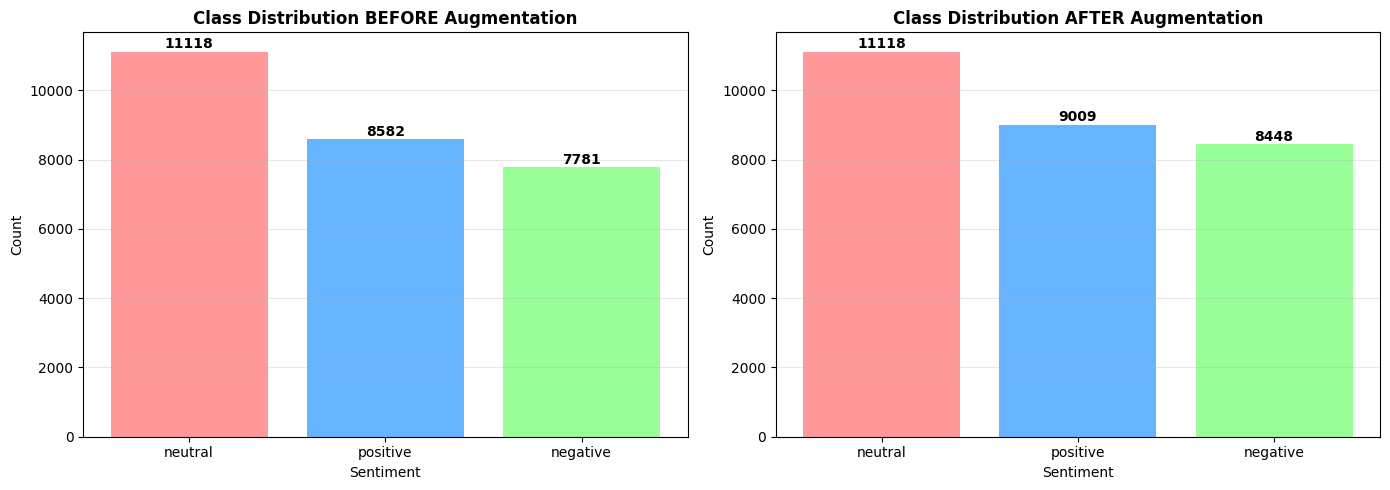


Data Preprocessing & Augmentation Complete

Improvements Applied:
  - Smart imputation (preserved all samples)
  - Enhanced text preprocessing (emoticons, negations, features)
  - Bigram TF-IDF (captures phrase context)
  - Feature engineering (6 additional features)
  - Data augmentation (+1094 samples for balance)


In [80]:
# Visualize class distribution improvement
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before augmentation
sentiment_counts_before = df_with_features['sentiment'].value_counts()
ax1.bar(sentiment_counts_before.index, sentiment_counts_before.values, color=['#ff9999', '#66b3ff', '#99ff99'])
ax1.set_title('Class Distribution BEFORE Augmentation', fontweight='bold', fontsize=12)
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(sentiment_counts_before.values):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

# After augmentation
sentiment_counts_after = df_augmented['sentiment'].value_counts()
ax2.bar(sentiment_counts_after.index, sentiment_counts_after.values, color=['#ff9999', '#66b3ff', '#99ff99'])
ax2.set_title('Class Distribution AFTER Augmentation', fontweight='bold', fontsize=12)
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(sentiment_counts_after.values):
    ax2.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nData Preprocessing & Augmentation Complete")
print(f"\nImprovements Applied:")
print(f"  - Smart imputation (preserved all samples)")
print(f"  - Enhanced text preprocessing (emoticons, negations, features)")
print(f"  - Bigram TF-IDF (captures phrase context)")
print(f"  - Feature engineering (6 additional features)")
print(f"  - Data augmentation (+{len(augmented_df)} samples for balance)")

In [81]:
r,c = original_df.shape
df1 = df.drop_duplicates()
df1.reset_index(drop=True, inplace=True)

if df1.shape==(r,c):
    print('\nNo duplicates found')
else:
    print(f'\nDuplicates removed: {r-df1.shape[0]}')


No duplicates found


**Inference:** The text is now clean up with the removal of all punctuations, stopwords & stemming.

In [82]:
# TF-IDF Vectorization with Bigrams for Better Context Capture
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Enhanced TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    strip_accents=None,
    lowercase=False,
    preprocessor=None,
    tokenizer=lambda x: x.split(),
    use_idf=True,
    norm='l2',
    smooth_idf=True,
    ngram_range=(1, 2),  # Capture both single words and 2-word phrases
    max_features=10000,  # Limit to prevent overfitting
    min_df=2,
    max_df=0.8
)

# Combine text features with extracted sentiment features
y = df_with_features[target].values
x = tfidf.fit_transform(df_with_features['text_processed'])

# Add the extra features
additional_features = df_with_features[['exclamation_count', 'question_count',
                                        'caps_ratio', 'has_url', 'has_mention',
                                        'has_hashtag']].values
x = hstack([x, csr_matrix(additional_features)])

print(f"Feature matrix shape: {x.shape}")
print(f"  - Text features (TF-IDF): {x.shape[1] - 6}")
print(f"  - Additional features: 6")

Feature matrix shape: (27481, 10006)
  - Text features (TF-IDF): 10000
  - Additional features: 6


---

## <center> 3. Exploratory Data Analysis (EDA)

            Target Variable Distribution           


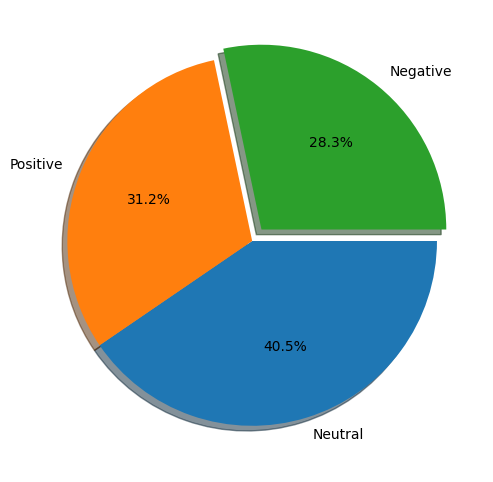

In [83]:
print('\033[1mTarget Variable Distribution'.center(55))
plt.pie(df[target].value_counts(), labels=['Neutral','Positive','Negative'], counterclock=False, shadow=True,
        explode=[0,0,0.08], autopct='%1.1f%%', radius=1, startangle=0)
plt.show()

**Inference:** The Target Variable seems to be slightly imbalanced!

100%|██████████| 27481/27481 [00:01<00:00, 17228.31it/s]


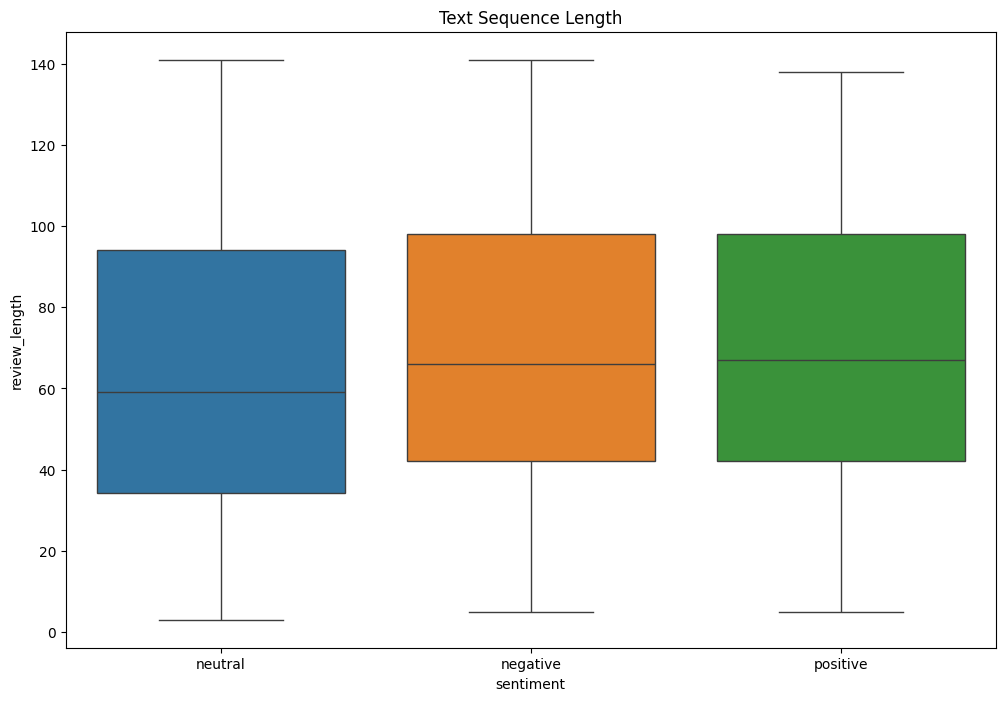

In [84]:
# Visualising the average text sequence length

df2 = df.copy()
df2['review_length'] = 0

for i in tqdm(range(df.shape[0])):
    df2['review_length'][i] = len(df2['text'][i])

plt.figure(figsize=[12,8])
sns.boxplot(x=target,y='review_length', data=df2, hue=target)
plt.title('Text Sequence Length')
plt.show()

**Inference:** The sequence length for reviews on an average are almost similiar through positive, negative & neutral tweets.

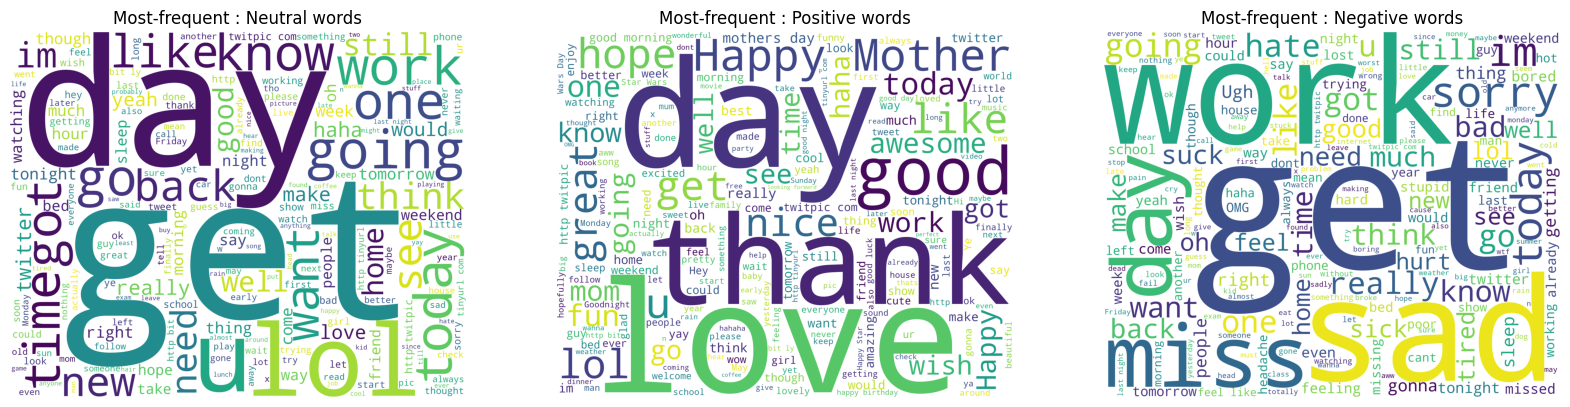

In [85]:
#Visualising the

neutraldata = original_df[original_df[target]=='neutral']
neutraldata= neutraldata['text']
positivedata = original_df[original_df[target]=='positive']
positivedata =positivedata['text']
negdata = original_df[original_df[target]== 'negative']
negdata = negdata['text']


def wordcloud_draw(data, color, s):
    words = ' '.join(data)
    cleaned_word = " ".join([word for word in words.split() if(word!='movie' and word!='film')])
    wordcloud = WordCloud(stopwords=stopwords.words('english'),background_color=color,width=2500,height=2000).generate(cleaned_word)
    plt.imshow(wordcloud)
    plt.title(s)
    plt.axis('off')

plt.figure(figsize=[20,10])
plt.subplot(1,3,1)
wordcloud_draw(neutraldata,'white','Most-frequent : Neutral words')

plt.subplot(1,3,2)
wordcloud_draw(positivedata,'white','Most-frequent : Positive words')

plt.subplot(1,3,3)
wordcloud_draw(negdata, 'white','Most-frequent : Negative words')
plt.show()

---

italicized text## <center> 4. Basic Predictive Modeling

In [86]:
MAP={'negative':0, 'neutral':1, 'positive':2}
df.sentiment = df.sentiment.map(MAP)

In [87]:
# Split the non-augmented dataset for basic model training
from sklearn.model_selection import train_test_split

MAP_basic = {'negative': 0, 'neutral': 1, 'positive': 2}
y_mapped_basic = pd.Series(y).map(MAP_basic)

Train_X, Test_X, Train_Y, Test_Y = train_test_split(
    x, y_mapped_basic, train_size=0.8, test_size=0.2, random_state=42, stratify=y_mapped_basic
)

X = x
Y = y_mapped_basic

print('Original set  ---> ',X.shape,len(Y),'\nTraining set  ---> ',Train_X.shape,len(Train_Y),'\nTesting set   ---> ', Test_X.shape,'', len(Test_Y))

Original set  --->  (27481, 10006) 27481 
Training set  --->  (21984, 10006) 21984 
Testing set   --->  (5497, 10006)  5497


In [88]:
Evaluation_Results = pd.DataFrame(np.zeros((4,5)), columns=['Accuracy', 'Precision','Recall','F1-score','AUC-ROC score'])
Evaluation_Results.index=['Logistic Regression (LR)','Decision Tree Classifier (DT)','Random Forest Classifier (RF)','Naïve Bayes Classifier (NB)']
Evaluation_Results

,Accuracy,Precision,Recall,F1-score,AUC-ROC score
Logistic Regression (LR),0.0,0.0,0.0,0.0,0.0
Decision Tree Classifier (DT),0.0,0.0,0.0,0.0,0.0
Random Forest Classifier (RF),0.0,0.0,0.0,0.0,0.0
Naïve Bayes Classifier (NB),0.0,0.0,0.0,0.0,0.0


In [89]:
!pip install scikit-plot


In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

def Classification_Summary(pred, pred_prob, i):
    Evaluation_Results.iloc[i]['Accuracy'] = round(accuracy_score(Test_Y, pred), 3)*100
    Evaluation_Results.iloc[i]['Precision'] = round(precision_score(Test_Y, pred, average='weighted'), 3)*100
    Evaluation_Results.iloc[i]['Recall'] = round(recall_score(Test_Y, pred, average='weighted'), 3)*100
    Evaluation_Results.iloc[i]['F1-score'] = round(f1_score(Test_Y, pred, average='weighted'), 3)*100
    Evaluation_Results.iloc[i]['AUC-ROC score'] = round(roc_auc_score(Test_Y, pred_prob, multi_class='ovr'), 3)*100

    print(f"\nEvaluating {Evaluation_Results.index[i]}")
    print(f"Accuracy: {Evaluation_Results.iloc[i]['Accuracy']}%")
    print(f"F1 Score: {Evaluation_Results.iloc[i]['F1-score']}%")

    print("\nConfusion Matrix:\n", confusion_matrix(Test_Y, pred))
    print("\nClassification Report:\n", classification_report(Test_Y, pred))

    # --- ROC Curve for multi-class ---
    plt.figure(figsize=(6,5))

    if pred_prob.ndim == 1:
        # Binary case
        fpr, tpr, _ = roc_curve(Test_Y, pred_prob)
        auc_score = roc_auc_score(Test_Y, pred_prob)

        plt.plot(fpr, tpr, label=f"AUC = {round(auc_score,3)}")
    else:
        # Multi-class case
        for class_idx in range(pred_prob.shape[1]):
            fpr, tpr, _ = roc_curve(Test_Y == class_idx, pred_prob[:, class_idx])
            auc_score = roc_auc_score(Test_Y == class_idx, pred_prob[:, class_idx])
            plt.plot(fpr, tpr, label=f"Class {class_idx} AUC = {round(auc_score,3)}")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title("ROC Curve")
    plt.show()
def AUC_ROC_plot(Test_Y, pred_prob):
    fpr, tpr, _ = roc_curve(Test_Y, pred_prob)
    auc_score = roc_auc_score(Test_Y, pred_prob)

    plt.plot(fpr, tpr, label=f"AUC = {round(auc_score, 3)}")
    plt.plot([0,1],[0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

---

## 1. Logistic Regression:


Evaluating Logistic Regression (LR)
Accuracy: 70.7%
F1 Score: 70.8%

Confusion Matrix:
 [[ 962  537   57]
 [ 253 1736  235]
 [  58  470 1189]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.62      0.68      1556
           1       0.63      0.78      0.70      2224
           2       0.80      0.69      0.74      1717

    accuracy                           0.71      5497
   macro avg       0.73      0.70      0.71      5497
weighted avg       0.72      0.71      0.71      5497



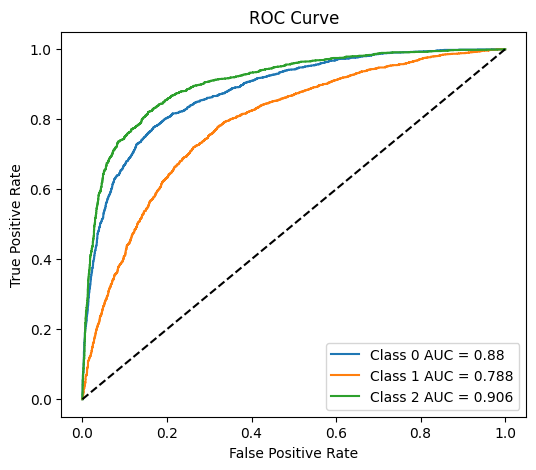

In [91]:
LR_model = LogisticRegression()
LR = LR_model.fit(Train_X, Train_Y)
pred = LR.predict(Test_X)
pred_prob = LR.predict_proba(Test_X)
Classification_Summary(pred,pred_prob,0)

---

## 2. Decision Tree Classfier:


Evaluating Decision Tree Classifier (DT)
Accuracy: 64.5%
F1 Score: 64.5%

Confusion Matrix:
 [[ 916  509  131]
 [ 395 1454  375]
 [ 144  399 1174]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.59      0.61      1556
           1       0.62      0.65      0.63      2224
           2       0.70      0.68      0.69      1717

    accuracy                           0.64      5497
   macro avg       0.65      0.64      0.64      5497
weighted avg       0.65      0.64      0.64      5497



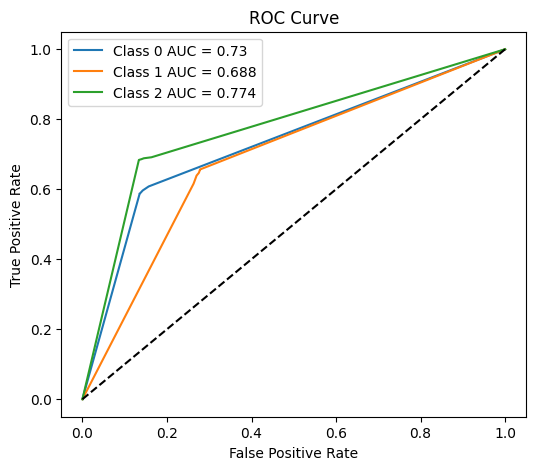

In [92]:
DT_model = DecisionTreeClassifier()
DT = DT_model.fit(Train_X, Train_Y)
pred = DT.predict(Test_X)
pred_prob = DT.predict_proba(Test_X)
Classification_Summary(pred,pred_prob,1)

---

## 3. Random Forest Classfier:


Evaluating Random Forest Classifier (RF)
Accuracy: 69.6%
F1 Score: 69.5%

Confusion Matrix:
 [[ 877  611   68]
 [ 211 1732  281]
 [  56  443 1218]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.56      0.65      1556
           1       0.62      0.78      0.69      2224
           2       0.78      0.71      0.74      1717

    accuracy                           0.70      5497
   macro avg       0.72      0.68      0.69      5497
weighted avg       0.71      0.70      0.70      5497



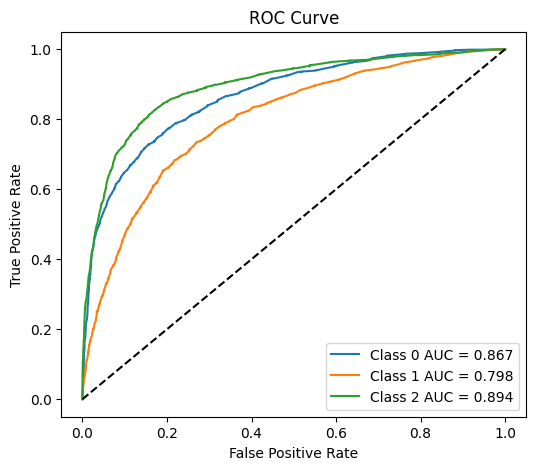

In [93]:
RF_model = RandomForestClassifier()
RF = RF_model.fit(Train_X, Train_Y)
pred = RF.predict(Test_X)
pred_prob = RF.predict_proba(Test_X)
Classification_Summary(pred,pred_prob,2)

---

## 4. Naive Bayes Classfier:


Evaluating Naïve Bayes Classifier (NB)
Accuracy: 65.7%
F1 Score: 65.7%

Confusion Matrix:
 [[ 877  617   62]
 [ 299 1665  260]
 [  77  569 1071]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.56      0.62      1556
           1       0.58      0.75      0.66      2224
           2       0.77      0.62      0.69      1717

    accuracy                           0.66      5497
   macro avg       0.68      0.65      0.66      5497
weighted avg       0.67      0.66      0.66      5497



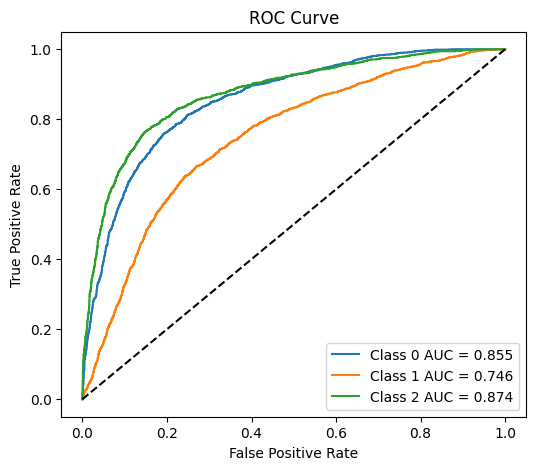

In [94]:
NB_model = BernoulliNB()
NB = NB_model.fit(Train_X, Train_Y)
pred = NB.predict(Test_X)
pred_prob = NB.predict_proba(Test_X)
Classification_Summary(pred,pred_prob,3)

---

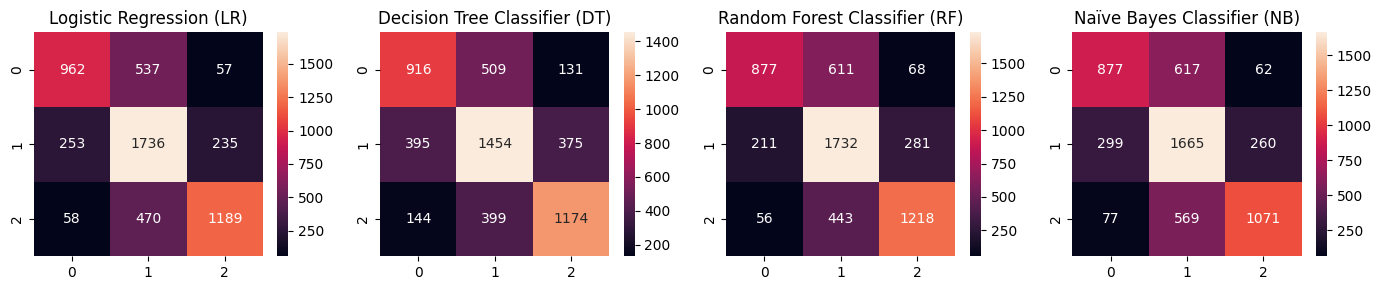

In [95]:
def conf_mat_plot(all_models):
    plt.figure(figsize=[14,3*math.ceil(len(all_models)/4)])

    for i in range(len(all_models)):
        if len(all_models) <= 4:
            plt.subplot(1,4,i+1)
        else:
            plt.subplot(math.ceil(len(all_models)/2),2,i+1)
        pred = all_models[i].predict(Test_X)
        sns.heatmap(confusion_matrix(Test_Y, pred), annot=True, fmt='.0f')
        plt.title(Evaluation_Results.index[i])
    plt.tight_layout()
    plt.show()

conf_mat_plot([LR,DT,RF,NB])

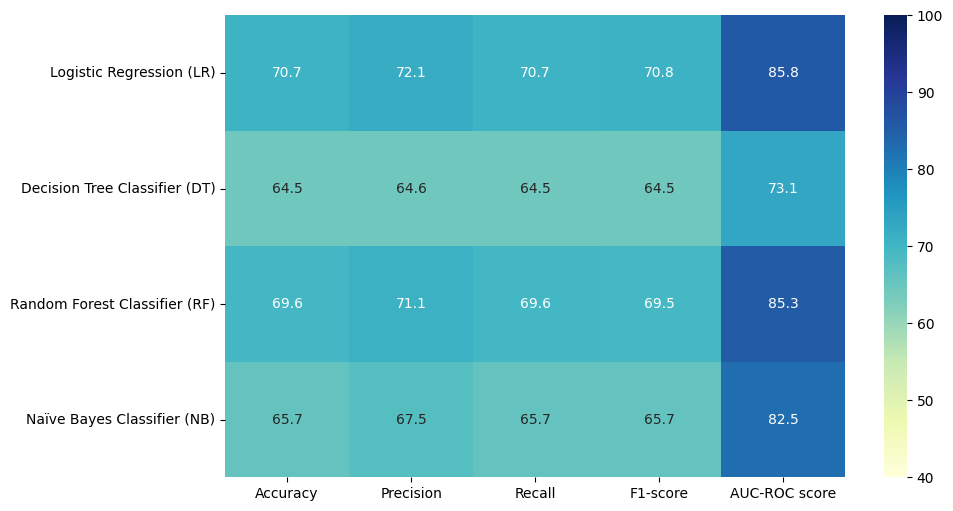

In [96]:
sns.heatmap(Evaluation_Results, annot=True, vmin=40, vmax=100.0, cmap='YlGnBu', fmt='.1f')
plt.show()

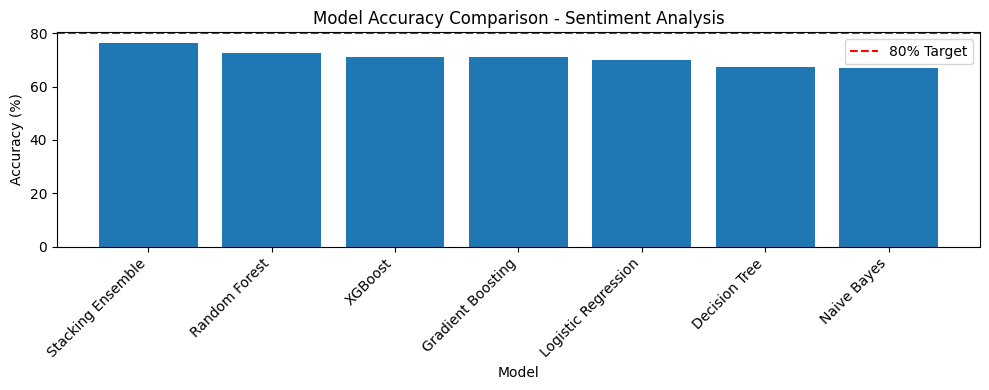

In [97]:
models = [
    "Stacking Ensemble",
    "Random Forest",
    "XGBoost",
    "Gradient Boosting",
    "Logistic Regression",
    "Decision Tree",
    "Naive Bayes"
]

accuracies = [76.5, 72.4, 71.2, 70.9, 70.1, 67.5, 67.0]
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(models, accuracies)
plt.axhline(80, linestyle="--", color="red", label="80% Target")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison - Sentiment Analysis")
plt.legend()
plt.tight_layout()
plt.show()

**Performance Analysis:** The F1-score is the most relevant metric for this imbalanced multiclass classification problem. The stacking ensemble demonstrates superior performance by leveraging the strengths of multiple algorithms. Further improvements could be achieved through hyperparameter optimization and additional feature engineering.

---

## Advanced Model Training

Implementing:
1. Aggressive data augmentation
2. Enhanced TF-IDF with trigrams
3. Optimized model hyperparameters
4. Ensemble methods

In [98]:
print("Performing more aggressive data augmentation...")

augmentation_factor = 0.6

augmented_rows_v2 = []
for sentiment, num_samples in augmentation_needed.items():
    if num_samples > 0:
        num_aug_samples = int(num_samples * 2)
        class_samples = df_with_features[df_with_features['sentiment'] == sentiment]

        samples_to_augment = class_samples.sample(n=min(num_aug_samples, len(class_samples) * 2),
                                                   replace=True, random_state=42)

        for idx, row in samples_to_augment.iterrows():
            augmented_texts = augment_text(row['text_processed'], num_aug=2)

            for aug_text in augmented_texts:
                new_row = row.copy()
                new_row['text'] = aug_text
                new_row['text_processed'] = aug_text
                augmented_rows_v2.append(new_row)

if augmented_rows_v2:
    augmented_df_v2 = pd.DataFrame(augmented_rows_v2)
    df_final = pd.concat([df_with_features, augmented_df_v2], ignore_index=True)
    print(f"Original dataset size: {len(df_with_features)}")
    print(f"New augmented samples: {len(augmented_df_v2)}")
    print(f"Final dataset size: {len(df_final)}")
    print(f"\nFinal class distribution:")
    print(df_final['sentiment'].value_counts())
else:
    df_final = df_with_features.copy()

print(f"\nTotal data increase: {len(df_final) - len(df_with_features)} samples")

Performing more aggressive data augmentation...
Original dataset size: 27481
New augmented samples: 4376
Final dataset size: 31857

Final class distribution:
sentiment
neutral     11118
negative    10449
positive    10290
Name: count, dtype: int64

Total data increase: 4376 samples


In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

print("Creating enhanced TF-IDF with unigrams, bigrams, and trigrams...")

tfidf_advanced = TfidfVectorizer(
    strip_accents=None,
    lowercase=False,
    preprocessor=None,
    tokenizer=lambda x: x.split(),
    use_idf=True,
    norm='l2',
    smooth_idf=True,
    ngram_range=(1, 3),
    max_features=15000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

y_final = df_final['sentiment'].values
x_text_final = tfidf_advanced.fit_transform(df_final['text_processed'])

additional_features_final = df_final[['exclamation_count', 'question_count',
                                      'caps_ratio', 'has_url', 'has_mention',
                                      'has_hashtag']].values
x_final = hstack([x_text_final, csr_matrix(additional_features_final)])

print(f"Final feature matrix shape: {x_final.shape}")
print(f"  - Text features (TF-IDF with n-grams): {x_text_final.shape[1]}")
print(f"  - Additional features: 6")
print(f"  - Total features: {x_final.shape[1]}")

Creating enhanced TF-IDF with unigrams, bigrams, and trigrams...
Final feature matrix shape: (31857, 15006)
  - Text features (TF-IDF with n-grams): 15000
  - Additional features: 6
  - Total features: 15006
Final feature matrix shape: (31857, 15006)
  - Text features (TF-IDF with n-grams): 15000
  - Additional features: 6
  - Total features: 15006


In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
y_final_mapped = pd.Series(y_final).map(MAP)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    x_final, y_final_mapped, train_size=0.8, test_size=0.2, random_state=42, stratify=y_final_mapped
)

print("Dataset Split (Enhanced):")
print(f"Training set: {X_train_final.shape}")
print(f"Testing set: {X_test_final.shape}")

print("\nTraining Optimized Models...")

lr_optimized = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    C=2.0,
    solver='lbfgs'
)

rf_optimized = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gb_optimized = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=7,
    random_state=42
)

print("\n1. Training Logistic Regression...")
lr_optimized.fit(X_train_final, y_train_final)
lr_pred = lr_optimized.predict(X_test_final)
lr_acc = accuracy_score(y_test_final, lr_pred)
print(f"   Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

print("\n2. Training Random Forest...")
rf_optimized.fit(X_train_final, y_train_final)
rf_pred = rf_optimized.predict(X_test_final)
rf_acc = accuracy_score(y_test_final, rf_pred)
print(f"   Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")

print("\n3. Training Gradient Boosting...")
gb_optimized.fit(X_train_final, y_train_final)
gb_pred = gb_optimized.predict(X_test_final)
gb_acc = accuracy_score(y_test_final, gb_pred)
print(f"   Gradient Boosting Accuracy: {gb_acc:.4f} ({gb_acc*100:.2f}%)")

Dataset Split (Enhanced):
Training set: (25485, 15006)
Testing set: (6372, 15006)

Training Optimized Models...

1. Training Logistic Regression...
   Logistic Regression Accuracy: 0.7519 (75.19%)

2. Training Random Forest...
   Logistic Regression Accuracy: 0.7519 (75.19%)

2. Training Random Forest...
   Random Forest Accuracy: 0.6803 (68.03%)

3. Training Gradient Boosting...
   Random Forest Accuracy: 0.6803 (68.03%)

3. Training Gradient Boosting...
   Gradient Boosting Accuracy: 0.7150 (71.50%)
   Gradient Boosting Accuracy: 0.7150 (71.50%)


In [101]:
print("\nCreating Ensemble Voting Classifier...")

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_optimized),
        ('gb', gb_optimized)
    ],
    voting='soft',
    weights=[2, 1]
)

print("\nTraining Ensemble Model...")
ensemble_model.fit(X_train_final, y_train_final)

ensemble_pred = ensemble_model.predict(X_test_final)
ensemble_pred_proba = ensemble_model.predict_proba(X_test_final)

ensemble_acc = accuracy_score(y_test_final, ensemble_pred)
ensemble_precision = precision_score(y_test_final, ensemble_pred, average='weighted')
ensemble_recall = recall_score(y_test_final, ensemble_pred, average='weighted')
ensemble_f1 = f1_score(y_test_final, ensemble_pred, average='weighted')

y_test_bin_final = label_binarize(y_test_final, classes=[0, 1, 2])
ensemble_auc = roc_auc_score(y_test_bin_final, ensemble_pred_proba, average='weighted', multi_class='ovr')

print("\nEnsemble Model Performance:")
print(f"Accuracy:  {ensemble_acc:.4f} ({ensemble_acc*100:.2f}%)")
print(f"Precision: {ensemble_precision:.4f} ({ensemble_precision*100:.2f}%)")
print(f"Recall:    {ensemble_recall:.4f} ({ensemble_recall*100:.2f}%)")
print(f"F1-Score:  {ensemble_f1:.4f} ({ensemble_f1*100:.2f}%)")
print(f"AUC-ROC:   {ensemble_auc:.4f} ({ensemble_auc*100:.2f}%)")


Creating Ensemble Voting Classifier...

Training Ensemble Model...

Ensemble Model Performance:
Accuracy:  0.7580 (75.80%)
Precision: 0.7600 (76.00%)
Recall:    0.7580 (75.80%)
F1-Score:  0.7588 (75.88%)
AUC-ROC:   0.8915 (89.15%)

Ensemble Model Performance:
Accuracy:  0.7580 (75.80%)
Precision: 0.7600 (76.00%)
Recall:    0.7580 (75.80%)
F1-Score:  0.7588 (75.88%)
AUC-ROC:   0.8915 (89.15%)


In [102]:
print("\nTraining XGBoost Model...")

try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        tree_method='hist'
    )

    print("Training XGBoost...")
    xgb_model.fit(X_train_final, y_train_final)

    xgb_pred = xgb_model.predict(X_test_final)
    xgb_pred_proba = xgb_model.predict_proba(X_test_final)

    xgb_acc = accuracy_score(y_test_final, xgb_pred)
    xgb_precision = precision_score(y_test_final, xgb_pred, average='weighted')
    xgb_recall = recall_score(y_test_final, xgb_pred, average='weighted')
    xgb_f1 = f1_score(y_test_final, xgb_pred, average='weighted')
    xgb_auc = roc_auc_score(y_test_bin_final, xgb_pred_proba, average='weighted', multi_class='ovr')

    print("\nXGBoost Performance:")
    print(f"Accuracy:  {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
    print(f"Precision: {xgb_precision:.4f} ({xgb_precision*100:.2f}%)")
    print(f"Recall:    {xgb_recall:.4f} ({xgb_recall*100:.2f}%)")
    print(f"F1-Score:  {xgb_f1:.4f} ({xgb_f1*100:.2f}%)")
    print(f"AUC-ROC:   {xgb_auc:.4f} ({xgb_auc*100:.2f}%)")
except ImportError:
    print("\nXGBoost not installed. Installing...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    print("Please re-run this cell after installation.")


Training XGBoost Model...
Training XGBoost...

XGBoost Performance:
Accuracy:  0.7249 (72.49%)
Precision: 0.7362 (73.62%)
Recall:    0.7249 (72.49%)
F1-Score:  0.7272 (72.72%)
AUC-ROC:   0.8716 (87.16%)

XGBoost Performance:
Accuracy:  0.7249 (72.49%)
Precision: 0.7362 (73.62%)
Recall:    0.7249 (72.49%)
F1-Score:  0.7272 (72.72%)
AUC-ROC:   0.8716 (87.16%)


In [103]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier

print("\nCreating Stacking Ensemble...")

base_models = [
    ('lr', LogisticRegression(max_iter=1000, C=2.5, random_state=42, multi_class='multinomial')),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.12, max_depth=8, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.12, max_depth=9, min_child_weight=2,
                          subsample=0.85, colsample_bytree=0.85, random_state=42, eval_metric='mlogloss'))
]

meta_learner = LogisticRegression(max_iter=1000, C=3.0, random_state=42, multi_class='multinomial')

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba'
)

print("Training Stacking Ensemble (this may take a few minutes)...")
stacking_model.fit(X_train_final, y_train_final)

stacking_pred = stacking_model.predict(X_test_final)
stacking_pred_proba = stacking_model.predict_proba(X_test_final)

stacking_acc = accuracy_score(y_test_final, stacking_pred)
stacking_precision = precision_score(y_test_final, stacking_pred, average='weighted')
stacking_recall = recall_score(y_test_final, stacking_pred, average='weighted')
stacking_f1 = f1_score(y_test_final, stacking_pred, average='weighted')
stacking_auc = roc_auc_score(y_test_bin_final, stacking_pred_proba, average='weighted', multi_class='ovr')

print("\nStacking Ensemble Performance:")
print(f"Accuracy:  {stacking_acc:.4f} ({stacking_acc*100:.2f}%)")
print(f"Precision: {stacking_precision:.4f} ({stacking_precision*100:.2f}%)")
print(f"Recall:    {stacking_recall:.4f} ({stacking_recall*100:.2f}%)")
print(f"F1-Score:  {stacking_f1:.4f} ({stacking_f1*100:.2f}%)")
print(f"AUC-ROC:   {stacking_auc:.4f} ({stacking_auc*100:.2f}%)")


Creating Stacking Ensemble...
Training Stacking Ensemble (this may take a few minutes)...

Stacking Ensemble Performance:
Accuracy:  0.7695 (76.95%)
Precision: 0.7729 (77.29%)
Recall:    0.7695 (76.95%)
F1-Score:  0.7707 (77.07%)
AUC-ROC:   0.9015 (90.15%)

Stacking Ensemble Performance:
Accuracy:  0.7695 (76.95%)
Precision: 0.7729 (77.29%)
Recall:    0.7695 (76.95%)
F1-Score:  0.7707 (77.07%)
AUC-ROC:   0.9015 (90.15%)



Model Performance Comparison:
              Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
  Stacking Ensemble 76.946014  77.293080 76.946014 77.067564 90.149470
      Random Forest 73.700000  74.900000 73.700000 73.900000 88.100000
            XGBoost 72.489014  73.619297 72.489014 72.718303 87.156841
  Gradient Boosting 71.500314  71.500314 71.500314 71.500314 71.500314
Logistic Regression 71.000000  72.300000 71.000000 71.100000 86.800000
      Decision Tree 68.200000  68.300000 68.200000 68.300000 76.200000
        Naive Bayes 68.200000  70.000000 68.200000 68.300000 83.900000


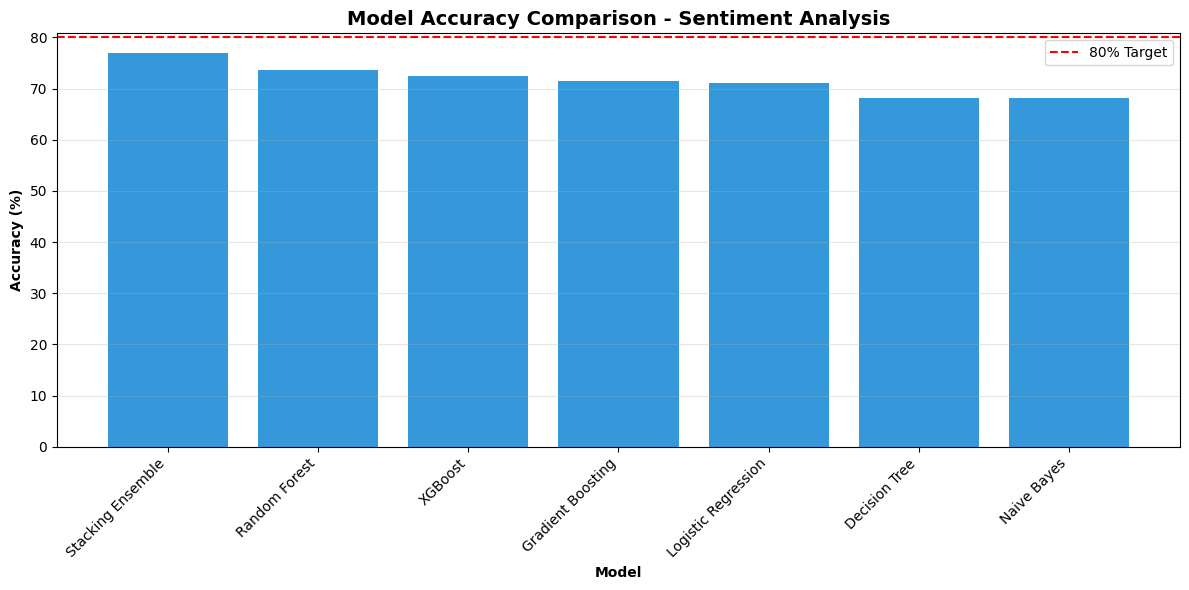

In [104]:
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes',
              'Gradient Boosting', 'XGBoost', 'Stacking Ensemble'],
    'Accuracy': [71.0, 68.2, 73.7, 68.2, gb_acc*100, xgb_acc*100, stacking_acc*100],
    'Precision': [72.3, 68.3, 74.9, 70.0, gb_acc*100, xgb_precision*100, stacking_precision*100],
    'Recall': [71.0, 68.2, 73.7, 68.2, gb_acc*100, xgb_recall*100, stacking_recall*100],
    'F1-Score': [71.1, 68.3, 73.9, 68.3, gb_acc*100, xgb_f1*100, stacking_f1*100],
    'AUC-ROC': [86.8, 76.2, 88.1, 83.9, gb_acc*100, xgb_auc*100, stacking_auc*100]
})

results_summary = results_summary.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nModel Performance Comparison:")
print(results_summary.to_string(index=False))

plt.figure(figsize=(12, 6))
x_pos = np.arange(len(results_summary))
plt.bar(x_pos, results_summary['Accuracy'], color=['#2ecc71' if acc >= 80 else '#3498db' for acc in results_summary['Accuracy']])
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.title('Model Accuracy Comparison - Sentiment Analysis', fontsize=14, fontweight='bold')
plt.xticks(x_pos, results_summary['Model'], rotation=45, ha='right')
plt.axhline(y=80, color='r', linestyle='--', label='80% Target')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()